<a href="https://colab.research.google.com/github/leonidasf300/OUU2026/blob/main/LeonSerna_OUU_project_v1_simple_feeder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simple feeder to do a simple model
v1 cleaning this notebook

# Installing libraries

In [1]:
pip install pandapower[all]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.0/330.0 kB 15.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 16.1 MB/s eta 0:00:00


# Importing libraries

In [1]:
import pandapower as pp
import pandapower.shortcircuit as sc
import pandapower as pp
import pandapower.shortcircuit as sc
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt


# Creating IEC MG

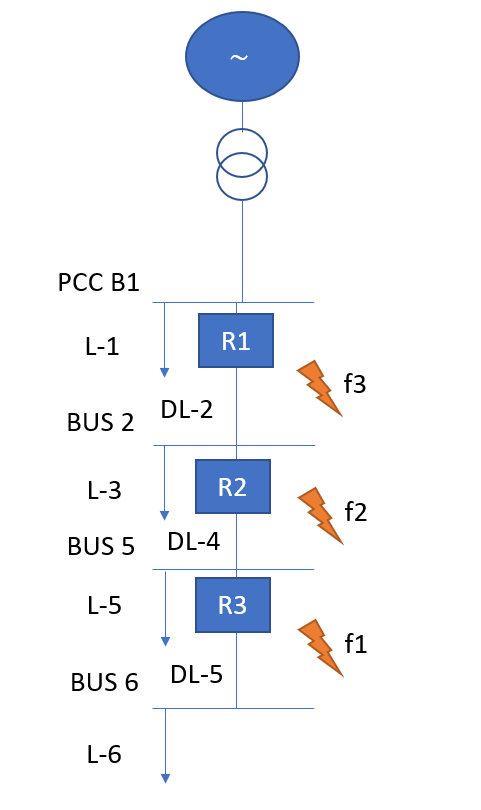

In [24]:


def create_iec_microgrid():
    # Crear red vacía
    net = pp.create_empty_network(f_hz=60.0)

    # ================= BUSES =================
    # Red de utilidad
    bus_utility = pp.create_bus(net, vn_kv=120.0, name="Utility 120kV")

    # Nivel de distribución 25 kV
    bus_pcc = pp.create_bus(net, vn_kv=25.0, name="PCC B1")
    bus2 = pp.create_bus(net, vn_kv=25.0, name="BUS 2")
    #bus3 = pp.create_bus(net, vn_kv=25.0, name="BUS 3")
    #bus4 = pp.create_bus(net, vn_kv=25.0, name="BUS 4")
    bus5 = pp.create_bus(net, vn_kv=25.0, name="BUS 5")
    bus6 = pp.create_bus(net, vn_kv=25.0, name="BUS 6")

    # Buses de Generadores (Baja Tensión)
    #bus_dg1 = pp.create_bus(net, vn_kv=2.4, name="Terminal DG1")
    #bus_dg2 = pp.create_bus(net, vn_kv=2.4, name="Terminal DG2")
    #bus_dg3 = pp.create_bus(net, vn_kv=0.575, name="Terminal DG3")
    #bus_dg4 = pp.create_bus(net, vn_kv=0.575, name="Terminal DG4")

    # ================= GRID EXTERNO =================
    # S_sc = 1000 MVA según Tabla 1
    pp.create_ext_grid(net, bus_utility, s_sc_max_mva=1000.0, rx_max=0.1, name="Utility Grid")

    # ================= TRANSFORMADORES =================
    # R1 = 0.00375 pu -> vkr = 0.375%
    # X1 = 0.1 pu (según artículo) -> vk = sqrt(0.00375^2 + 0.1^2) * 100 = 10.007%
    vkr_val = 0.00375 * 100
    vk_val = np.sqrt(0.00375**2 + 0.1**2) * 100


    # TR-1: 15 MVA, 120/25 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus_utility, lv_bus=bus_pcc, sn_mva=15.0,
                                          vn_hv_kv=120.0, vn_lv_kv=25.0, vkr_percent=vkr_val,
                                          vk_percent=vk_val, pfe_kw=30, i0_percent=0.2828, name="TR-1")
    """
    # TR-2 y TR-3: 12 MVA, 25/2.4 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus2, lv_bus=bus_dg1, sn_mva=12.0,
                                          vn_hv_kv=25.0, vn_lv_kv=2.4, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=24, i0_percent=0.2828, name="TR-2")
    pp.create_transformer_from_parameters(net, hv_bus=bus3, lv_bus=bus_dg2, sn_mva=12.0,
                                          vn_hv_kv=25.0, vn_lv_kv=2.4, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=24, i0_percent=0.2828, name="TR-3")

    # TR-4 y TR-5: 10 MVA, 25/0.575 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus4, lv_bus=bus_dg3, sn_mva=10.0,
                                          vn_hv_kv=25.0, vn_lv_kv=0.575, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=20, i0_percent=0.2828, name="TR-4")
    pp.create_transformer_from_parameters(net, hv_bus=bus6, lv_bus=bus_dg4, sn_mva=10.0,
                                          vn_hv_kv=25.0, vn_lv_kv=0.575, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=20, i0_percent=0.2828, name="TR-5")
    """

    # ================= LÍNEAS DE DISTRIBUCIÓN =================
    # R1 = 0.413 ohm/km, L1 = 3.32e-3 H/km -> X1 = 2*pi*60*3.32e-3 = 1.251 ohm/km
    # C1 = 5.01e-9 F/km
    line_params = {
    "r_ohm_per_km": 0.413,
    "x_ohm_per_km": 1.251,
    "c_nf_per_km": 5.01,
    "r0_ohm_per_km": 0.1153, # Datos de la Tabla 5
    "x0_ohm_per_km": 0.396,  # Calculado de L0
    "c0_nf_per_km": 11.33,   # Datos de la Tabla 5
    "max_i_ka": 1.0
}

    #pp.create_line_from_parameters(net, from_bus=bus_pcc, to_bus=bus3, length_km=30.0, name="DL-1", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus_pcc, to_bus=bus2, length_km=3.0, name="DL-2", **line_params)
    #pp.create_line_from_parameters(net, from_bus=bus2, to_bus=bus4, length_km=3.0, name="DL-3", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus2, to_bus=bus5, length_km=3.0, name="DL-4", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus5, to_bus=bus6, length_km=3.0, name="DL-5", **line_params)

    # Interruptores de lazo (Loop breakers) - Normalmente abiertos para operación radial
    #pp.create_switch(net, bus=bus2, element=bus4, et="b", closed=False, name="CB_LOOP 1")
    #pp.create_switch(net, bus=bus4, element=bus6, et="b", closed=False, name="CB_LOOP 2")

    # ================= GENERADORES DISTRIBUIDOS =================
    # DG1, DG2: Sincrónicos (9 MVA, xd'' = 0.177)
    #pp.create_gen(net, bus_dg1, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=2.4, xdss_pu=0.177, rdss_ohm=0.0, cos_phi=0.9, name="DG1")
    #pp.create_gen(net, bus_dg2, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=2.4, xdss_pu=0.177, rdss_ohm=0.0, cos_phi=0.9, name="DG2")

    # DG3: Inversor Eólico (6 MVA, xd'' = 0.252)
    #pp.create_gen(net, bus_dg3, p_mw=5.4, vm_pu=1.0, sn_mva=6.0, vn_kv=0.575, xdss_pu=0.252, rdss_ohm=0.0, cos_phi=0.9, name="DG3")

    # DG4: DFIG Eólico (9 MVA, Ls + Lr' = 0.34)
    #pp.create_gen(net, bus_dg4, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=0.575, xdss_pu=0.34, rdss_ohm=0.0, cos_phi=0.9, name="DG4")

    # ================= CARGAS =================
    # Total de 22 MW y 10 MVAR dividido en 6 cargas
    p_load = 22.0 / 6.0
    q_load = 10.0 / 6.0

    pp.create_load(net, bus_pcc, p_mw=p_load, q_mvar=q_load, name="L-1")
    pp.create_load(net, bus2, p_mw=p_load, q_mvar=q_load, name="L-2")
    #pp.create_load(net, bus3, p_mw=p_load, q_mvar=q_load, name="L-3")
    #pp.create_load(net, bus4, p_mw=p_load, q_mvar=q_load, name="L-4")
    pp.create_load(net, bus5, p_mw=p_load, q_mvar=q_load, name="L-5")
    pp.create_load(net, bus6, p_mw=p_load, q_mvar=q_load, name="L-6")

    return net

# Inicializar red
net = create_iec_microgrid()

# ================= ANÁLISIS DE CORTOCIRCUITO =================
# Ejecutar cortocircuito trifásico según norma IEC 60909
# case="max" para calcular corrientes máximas de falla
sc.calc_sc(net, case="max", ip=True, ith=True, branch_results=True)

# Imprimir resultados en buses (corriente de cortocircuito subtransitoria ikss)
print("--- Resultados de Cortocircuito en Buses (ikss en kA) ---")
print(net.res_bus_sc[['ikss_ka', 'ip_ka']])

--- Resultados de Cortocircuito en Buses (ikss en kA) ---
    ikss_ka      ip_ka
0  4.811252  11.880038
1  3.309837   8.765273
2  1.831511   4.161496
3  1.261011   2.723410
4  0.960669   2.023350


/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)
/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)


# Defining matrices

In [25]:

BACKUP = [[0,0,0],#R1
          [1,0,0],#R2
          [1,1,0]]#R3

CT_PS = [[800,0.5],#[[1200,1],#1
          [400,0.5],#6
          [400,0.5],#4
          [400,0.5]]#2

#             1,2,3,4
principal = [[0,0,0,1],
              [0,0,1,0],
              [0,1,0,0]]

faults = {"F1":"DL-5", "F2":"DL-4", "F3":"DL-2"}

In [26]:
headers = ["DG0", "DG1", "DG2", "DG3","DG4"]
rows = ["OM1","OM2","OM3","OM4"]

matrix = [[1,0,0,0,0],
          [1,1,1,1,1],
          [1,1,1,0,0],
          [0,1,1,1,1]]

OMS = {
    (rows[i], headers[j]): matrix[i][j]
    for i in range(len(rows))
    for j in range(len(headers))
}



In [27]:

Cindex={"STI":{"A":0.05,"B":0.04,"C":0},
        "SI":{"A":0.14,"B":0.02,"C":0},
        "VI":{"A":13.5,"B":1,"C":0}}
        # "EI":{"A":80,"B":2,"C":0},
        # "LTI":{"A":120,"B":1,"C":0},
        # "UI":{"A":315.2,"B":2.5,"C":0},
        # "IEEE-LTI":{"A":0.086,"B":0.05,"C":0.185},
        # "IEEE-LTVI":{"A":28.55,"B":2,"C":0.712},
        # "IEEE-LTEI":{"A":64.07,"B":2,"C":0.25},
        # "IEEE-MI":{"A":0.0515,"B":0.02,"C":0.114},
        # "IEEE-VI":{"A":19.61,"B":2,"C":0.491},
        # "IEEE-EI":{"A":28.2,"B":2,"C":0.1217},
        # "IEEE-STI":{"A":0.16758,"B":0.02,"C":0.11858},
        # "IEEE-STEI":{"A":1.281,"B":2,"C":0.005}}
C=["STI", "SI", "VI"]#,"EI","LTI","IEEE-LTI","IEEE-LTVI","IEEE-LTEI","IEEE-MI","IEEE-VI","IEEE-EI","IEEE-STI","IEEE-STEI"]


# Function calculate_sc_percentage

In [28]:
def calculate_sc_percentage(net, nombre_linea, pasos=10):
    # 1. Identificar la línea original
    line_idx = net.line[net.line.name == nombre_linea].index[0]
    bus_inicial = net.line.at[line_idx, "from_bus"]
    bus_final = net.line.at[line_idx, "to_bus"]
    L_total = net.line.at[line_idx, "length_km"]
    params = {
        "r_ohm_per_km": net.line.at[line_idx, "r_ohm_per_km"],
        "x_ohm_per_km": net.line.at[line_idx, "x_ohm_per_km"],
        "c_nf_per_km": net.line.at[line_idx, "c_nf_per_km"],
        "max_i_ka": net.line.at[line_idx, "max_i_ka"]
    }

    # 2. Desactivar la línea original
    net.line.at[line_idx, "in_service"] = False

    # Identificar las lineas de los relés y guardarlas directamente
    relay_idx = [
        net.line[net.line.name == "DL-2"].index[0],
        net.line[net.line.name == "DL-4"].index[0],
        net.line[net.line.name == "DL-5"].index[0]
    ]

    pos_virtual_line = relay_idx.index(line_idx)
    resultados = []

    # 3. Iterar cada 10% (o el paso definido)
    for i in range(1, pasos):
        porcentaje = i / pasos
        distancia_falla = L_total * porcentaje

        # Crear bus temporal de falla
        f_bus = pp.create_bus(net, vn_kv=net.bus.at[bus_inicial, "vn_kv"], name=f"Falla_{int(porcentaje*100)}%")

        # Crear los dos tramos de línea que conectan al punto de falla
        l1 = pp.create_line_from_parameters(net, bus_inicial, f_bus, distancia_falla, name="tramo_A", **params)
        l2 = pp.create_line_from_parameters(net, f_bus, bus_final, L_total - distancia_falla, name="tramo_B", **params)
        relay_idx[pos_virtual_line] = l1


        # 4. Ejecutar SC con branch_results=True para ver qué ven los relés en los extremos
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sc.calc_sc(net, bus=f_bus, branch_results=True)

        # Guardar datos: I_total en falla, I que ve Relé inicial (l1), I que ve Relé final (l2)
        # resultados.append({
        #     "Porcentaje": f"{int(porcentaje*100)}%",
        #     "I_falla_total": net.res_bus_sc.ikss_ka.at[f_bus],
        #     "I_Relé_Front": net.res_line_sc.ikss_ka.at[l1],
        #     "I_Relé_Back": net.res_line_sc.ikss_ka.at[l2]
        # })
        #print(net.res_line_sc)
        resultados.append({
            "Porcentaje": porcentaje*100,
            "R0": net.res_line_sc.ikss_ka.at[relay_idx[0]]*1000,
            "R1": net.res_line_sc.ikss_ka.at[relay_idx[1]]*1000,
            "R2": net.res_line_sc.ikss_ka.at[relay_idx[2]]*1000
        })


        # Limpiar para no acumular líneas en el modelo
        pp.drop_lines(net, [l1, l2])
        pp.drop_buses(net, [f_bus])

    # Restaurar línea original
    net.line.at[line_idx, "in_service"] = True
    #return pd.DataFrame(resultados)
    return pd.DataFrame(resultados)

dftest=calculate_sc_percentage(net, nombre_linea="DL-4", pasos=10)
dftest

,Porcentaje,R0,R1,R2
0,10.0,1752.466600,1752.466600,0.0
1,20.0,1679.900233,1679.900233,0.0
2,30.0,1613.053966,1613.053966,0.0
3,40.0,1551.282537,1551.282537,0.0
4,50.0,1494.033467,1494.033467,0.0
5,60.0,1440.831087,1440.831087,0.0
6,70.0,1391.263733,1391.263733,0.0
7,80.0,1344.973400,1344.973400,0.0
8,90.0,1301.647328,1301.647328,0.0


# Beta equation

Base Time Factor Calculation ($\beta_{ficd}$)This equation determines the base time factor ($\beta$) for inverse overcurrent curves (IEC/IEEE), unifying the physical power system currents with the internal relay settings.

$$\beta_{ficd} = \frac{A_c}{\left(\frac{ICC_{ifd}}{Ipickup_i \times CTR_i}\right)^{B_c}-1}$$

* Variable Definitions:$ICC_{ifd}$: Short-circuit current on the primary side $[A]$ (obtained from simulations).
* $Ipickup_i$: Pickup current or tap of relay $i$ on the secondary side $[A]$.
* $CTR_i$: Current Transformer Ratio (CTR) associated with relay $i$ $(\frac{I_{nominal\_primary}}{I_{nominal\_secondary}})$.
* $A_c, B_c$: Mathematical constants defining the shape of the selected inverse curve $c$ (e.g., Very Inverse, Extremely Inverse).

*Consistency Note:* The product $(Ipickup_i \times CTR_i)$ translates the relay setting into primary amperes so it can be directly divided by the fault current.If the term inside the parentheses (PSM) is $\le 1$, it means the fault current is lower than the pickup setting; the relay will not operate, and the mathematical result will be negative (invalid).

In [29]:
Findex=[f"F{i+1}" for i in range(3)]
Rindex=[f"R{i+1}" for i in range(3)]

BETA=dict()
B=dict()

dsteps = 3
steps = [i / dsteps for i in range(1, dsteps)]

for fault in range(len(Findex)):
  ICC_fid = calculate_sc_percentage(net, nombre_linea=faults[Findex[fault]], pasos=dsteps)
  for index, ICCdata in ICC_fid.iterrows():
    for relay in range(len(Rindex)):
      for curve in range(len(C)):
        ICC = ICCdata[f"R{relay}"]
        dist_fault = ICCdata["Porcentaje"]
        #print(f"f:{fault},i:{relay},c:{curve},d:{dist_fault:.2f}")

        PSMif=(ICC)/(CT_PS[relay][0]*CT_PS[relay][1])
        #BETA[Findex[fault],Rindex[relay],C[curve]]=(Cindex[C[curve]]["A"])/((PSMif**Cindex[C[curve]]["B"])-1)
        BETA[Findex[fault],Rindex[relay],C[curve],steps[index]]=(Cindex[C[curve]]["A"])/((PSMif**Cindex[C[curve]]["B"])-1)


for main in range(len(Rindex)):
  for backup in range(len(Rindex)):
    B[Rindex[main],Rindex[backup]] = BACKUP[main][backup]


In [30]:
# Convert the BETA dictionary to a list of dictionaries for DataFrame creation
beta_data = []
for key, value in BETA.items():
    falla, rele, curva, distancia = key
    beta_data.append({
        'Falla': falla,
        'Rele': rele,
        'Curva': curva,
        'Distancia': distancia,
        'Beta': value
    })

# Create the DataFrame
beta_df = pd.DataFrame(beta_data)

# Display the first few rows of the DataFrame
display(beta_df.head())


,Falla,Rele,Curva,Distancia,Beta
0,F1,R1,STI,0.333333,1.166623
1,F1,R1,SI,0.333333,6.602352
2,F1,R1,VI,0.333333,7.276823
3,F1,R2,STI,0.333333,0.692737
4,F1,R2,SI,0.333333,3.948105


In [31]:
beta_df[beta_df["Rele"]=="R4"]

,Falla,Rele,Curva,Distancia,Beta


In [32]:
beta_df[beta_df["Beta"]>0]

,Falla,Rele,Curva,Distancia,Beta
0,F1,R1,STI,0.333333,1.166623
1,F1,R1,SI,0.333333,6.602352
2,F1,R1,VI,0.333333,7.276823
3,F1,R2,STI,0.333333,0.692737
4,F1,R2,SI,0.333333,3.948105
5,F1,R2,VI,0.333333,2.865992
6,F1,R3,STI,0.333333,0.692737
7,F1,R3,SI,0.333333,3.948105
8,F1,R3,VI,0.333333,2.865992
9,F1,R1,STI,0.666667,1.278674


In [33]:
beta_df[beta_df["Falla"]=="F2"]

,Falla,Rele,Curva,Distancia,Beta
18,F2,R1,STI,0.333333,0.880216
19,F2,R1,SI,0.333333,4.998243
20,F2,R1,VI,0.333333,4.530473
21,F2,R2,STI,0.333333,0.577934
22,F2,R2,SI,0.333333,3.304979
23,F2,R2,VI,0.333333,1.939755
24,F2,R3,STI,0.333333,-0.050000
25,F2,R3,SI,0.333333,-0.140000
26,F2,R3,VI,0.333333,-13.500000
27,F2,R1,STI,0.666667,0.968820


#Plot Beta


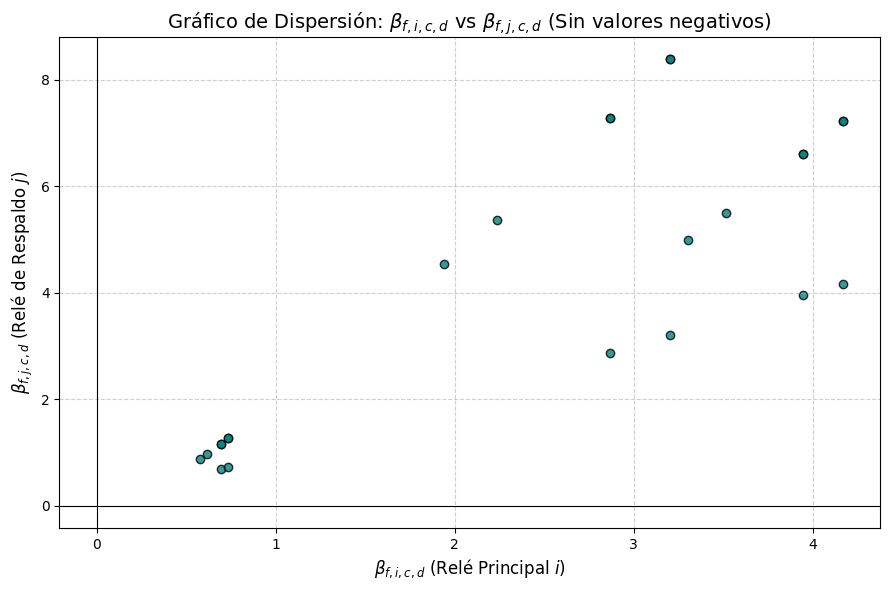

In [34]:
# 1. Filtrar los valores negativos directamente en el DataFrame
# Conservamos solo las filas donde Beta es mayor o igual a 0
df_filtrado = beta_df[beta_df['Beta'] >= 0]

# 2. Definir la matriz BACKUP y los nombres de los relés
BACKUP = [
    [0, 0, 0], # R1
    [1, 0, 0], # R2
    [1, 1, 0]  # R3
]
reles = ['R1', 'R2', 'R3']

# 3. Encontrar los pares (i, j) válidos iterando sobre la matriz
pares_ij = []
for idx_i, fila in enumerate(BACKUP):
    for idx_j, valor in enumerate(fila):
        if valor == 1:
            pares_ij.append((reles[idx_i], reles[idx_j]))

# 4. Extraer las coordenadas X e Y
puntos_x = []
puntos_y = []

# Agrupamos por las condiciones fijas usando el DataFrame ya filtrado
grupos = df_filtrado.groupby(['Falla','Distancia', 'Curva'])

for (f, c, d), grupo in grupos:
    # print(f, c, d)
    # print(grupo)
    for i, j in pares_ij:
        # Extraemos el valor para el relé principal (i)
        beta_i = grupo[grupo['Rele'] == i]['Beta'].values
        # Extraemos el valor para el relé de respaldo (j)
        beta_j = grupo[grupo['Rele'] == j]['Beta'].values

        # Solo agregamos el punto si AMBOS relés tienen datos válidos (positivos)
        if len(beta_i) > 0 and len(beta_j) > 0:
            puntos_x.append(beta_i[0])
            puntos_y.append(beta_j[0])

# 5. Configurar y mostrar la gráfica
plt.figure(figsize=(9, 6))
plt.scatter(puntos_x, puntos_y, color='teal', alpha=0.8, edgecolor='black')

# Formato matemático para los títulos
plt.title(r'Gráfico de Dispersión: $\beta_{f,i,c,d}$ vs $\beta_{f,j,c,d}$ (Sin valores negativos)', fontsize=14)
plt.xlabel(r'$\beta_{f,i,c,d}$ (Relé Principal $i$)', fontsize=12)
plt.ylabel(r'$\beta_{f,j,c,d}$ (Relé de Respaldo $j$)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.8) # Línea en Y=0
plt.axvline(0, color='black', linewidth=0.8) # Línea en X=0
plt.tight_layout()
plt.show()

In [35]:
beta_df.to_csv("beta_df.csv")

In [36]:
pares_ij

[('R2', 'R1'), ('R3', 'R1'), ('R3', 'R2')]

In [37]:
print(grupos.head())

   Falla Rele Curva  Distancia      Beta
0     F1   R1   STI   0.333333  1.166623
1     F1   R1    SI   0.333333  6.602352
2     F1   R1    VI   0.333333  7.276823
3     F1   R2   STI   0.333333  0.692737
4     F1   R2    SI   0.333333  3.948105
5     F1   R2    VI   0.333333  2.865992
6     F1   R3   STI   0.333333  0.692737
7     F1   R3    SI   0.333333  3.948105
8     F1   R3    VI   0.333333  2.865992
9     F1   R1   STI   0.666667  1.278674
10    F1   R1    SI   0.666667  7.229904
11    F1   R1    VI   0.666667  8.390589
12    F1   R2   STI   0.666667  0.731891
13    F1   R2    SI   0.666667  4.167434
14    F1   R2    VI   0.666667  3.200652
15    F1   R3   STI   0.666667  0.731891
16    F1   R3    SI   0.666667  4.167434
17    F1   R3    VI   0.666667  3.200652
18    F2   R1   STI   0.333333  0.880216
19    F2   R1    SI   0.333333  4.998243
20    F2   R1    VI   0.333333  4.530473
21    F2   R2   STI   0.333333  0.577934
22    F2   R2    SI   0.333333  3.304979
23    F2   R2   